# Εργασία Εξαμήνου — Μέρος B
## Κατηγοριοποίηση, Fusion και Αξιολόγηση


In [11]:
%pip install wordcloud nltk vaderSentiment matplotlib scikit-learn pandas numpy --quiet    

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tarfile
import bz2
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, silhouette_score, classification_report
)

from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

# Για ομοιόμορφα γραφήματα
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Ορισμός του random seed για αναπαραγωγιμότητα
SEED = 42

print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
## 0. Συλλογή Δεδομένων (Data Collection)

Οπως και στο Part A

Φορτώνουμε τα 5 αρχεία του dataset και τα συνδέουμε μέσω του κοινού πεδίου `id` (Song ID).  
Στόχος είναι να κρατήσουμε μόνο τα τραγούδια που έχουν δεδομένα και στις 3 κύριες πηγές: **Genre, Audio (MFCC), Lyrics**.

### 0.1 Φόρτωση Genres — Εύρεση Top-5

Κάθε τραγούδι μπορεί να ανήκει σε περισσότερα από ένα genres (comma-separated).  
Κρατάμε τη λίστα των genres αφαιρόντας duplicates , βρίσκουμε τα 5 πιο συχνά και φιλτράρουμε το dataset.

In [13]:
df_genres = pd.read_csv('id_genres.csv', sep='\t')
print(f'Γραμμές: {len(df_genres)}')
df_genres.head()

Γραμμές: 109269


,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [14]:
# Κρατάμε όλα τα genres ανά τραγούδι, χωρίς duplicates
df_genres['genre_list_unique'] = df_genres['genres'].str.split(',').apply(
    lambda x: list(dict.fromkeys(g.strip() for g in x))
)

# Flat λίστα genres για να βρούμε τα Top-5
all_genres_flat = df_genres.explode('genre_list_unique')['genre_list_unique']
top5_genres = all_genres_flat.value_counts().head(5).index.tolist()
print('Top-5 Genres:', top5_genres)

# Φιλτράρισμα σε song-level dataframe: κρατάμε τα τραγούδια που έχουν τουλάχιστον ένα Top-5 genre
df_genres_filtered = df_genres[['id', 'genre_list_unique']].copy()
df_genres_filtered = df_genres_filtered[df_genres_filtered['genre_list_unique'].apply(
    lambda genres: any(genre in top5_genres for genre in genres)
)].copy()

# Exploded view μόνο για genre counts / EDA όταν χρειάζεται
df_genres_exploded = df_genres_filtered.explode('genre_list_unique').copy()
df_genres_exploded.rename(columns={'genre_list_unique': 'genre'}, inplace=True)

print(f"Τραγούδια στα Top-5 Genres: {df_genres_filtered['id'].count()}")
print(f'Γραμμές στο exploded id-genre table: {len(df_genres_exploded)}')

Top-5 Genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']
Τραγούδια στα Top-5 Genres: 56100
Γραμμές στο exploded id-genre table: 134266


### 0.2 Φόρτωση Audio Features (MFCC Stats)

Το αρχείο είναι TSV συμπιεσμένο με bz2. Περιέχει 13 MFCC μέσους όρους και τον πίνακα συνδιακύμανσης (flattened upper triangle), συνολικά ~104 features ανά τραγούδι.  
Φιλτράρουμε μόνο τα IDs που μας ενδιαφέρουν για εξοικονόμηση μνήμης.

In [15]:
target_ids = set(df_genres_filtered['id'])

chunks = []
with bz2.open('id_mfcc_stats.tsv.bz2', 'rt') as f:
    for chunk in pd.read_csv(f, sep='\t', chunksize=1000):
        filtered = chunk[chunk['id'].isin(target_ids)]
        if not filtered.empty:
            chunks.append(filtered)

df_mfcc = pd.concat(chunks, ignore_index=True)
print(f'MFCC rows: {len(df_mfcc)}, columns: {len(df_mfcc.columns)}')
df_mfcc.head(2)

MFCC rows: 56100, columns: 105


,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,MFCC009,MFCC010,MFCC011,MFCC012,cov_0_0,cov_0_1,cov_0_2,cov_0_3,cov_0_4,cov_0_5,cov_0_6,cov_0_7,cov_0_8,cov_0_9,cov_0_10,cov_0_11,cov_0_12,cov_1_1,cov_1_2,cov_1_3,cov_1_4,cov_1_5,cov_1_6,cov_1_7,cov_1_8,cov_1_9,cov_1_10,cov_1_11,cov_1_12,cov_2_2,...,cov_4_9,cov_4_10,cov_4_11,cov_4_12,cov_5_5,cov_5_6,cov_5_7,cov_5_8,cov_5_9,cov_5_10,cov_5_11,cov_5_12,cov_6_6,cov_6_7,cov_6_8,cov_6_9,cov_6_10,cov_6_11,cov_6_12,cov_7_7,cov_7_8,cov_7_9,cov_7_10,cov_7_11,cov_7_12,cov_8_8,cov_8_9,cov_8_10,cov_8_11,cov_8_12,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,2.183189,-3.979188,1.629378,0.705899,0.974572,2.246267,-6.408308,-0.374022,-4.369574,-1.794488,-3.507640,1.707293,1.189804,-2.427518,-0.919464,-1.376686,2.01040,83.695127,-31.652354,-14.536801,-20.635775,-5.289088,-10.697877,-17.061431,-8.271930,-4.804691,6.612772,-2.495216,7.455067,164.07677,...,-1.600799,-12.673250,32.915646,-7.399619,131.520346,52.850127,25.010238,3.954419,10.639846,-4.255026,-19.579600,-15.518228,156.807276,-1.632275,20.176924,37.092571,4.309721,-15.836119,-35.301598,178.784428,10.604257,-27.443326,-24.822017,7.009793,6.521744,168.751391,28.154557,-15.699197,-10.133475,0.332801,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,-0.746395,-0.064056,0.301767,-5.916683,0.085596,-0.183584,0.306219,0.227496,0.630524,0.300581,-0.010894,0.606491,0.307999,-0.002997,0.260843,0.364520,0.61507,16.921757,2.106831,1.538642,-11.022237,-3.998472,-0.110400,-12.489524,-0.553862,-0.031234,-1.410510,-1.614436,-5.403153,23.76662,...,-1.571466,-0.677291,0.565654,7.319530,50.945415,22.106299,6.757878,4.501327,-5.622635,-8.429191,-6.583781,1.072703,56.286178,23.326891,4.668220,-7.606162,-3.582178,-4.824507,-3.783871,76.243016,23.312316,-2.753803,3.983190,3.038293,10.008256,73.769277,23.217555,0.653189,1.373774,1.554939,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903


### 0.3 Φόρτωση Tags

Τα tags είναι User-Generated Content — δίνουν την «ανθρώπινη» ερμηνεία κάθε τραγουδιού.

In [16]:
df_tags_raw = pd.read_csv('id_tags.csv', sep='\t')
df_tags = df_tags_raw[df_tags_raw['id'].isin(target_ids)][['id', 'tags']].copy()
print(f'Tags rows: {len(df_tags)}')
df_tags.head()

Tags rows: 56100


,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock,american artist"
5,00CH4HJdxQQQbJfu,"indie rock,experimental,indie,chillout,shoegaz..."
6,00DZ3XCAQb2FdCc6,"ambient,mellow,instrumental,easy listening,ele..."
8,00IeldeA9ijZOL0P,"pop,bollywood,one world,disney"


### 0.4 Φόρτωση Lyrics από tar.gz

Το αρχείο `processed_lyrics.tar.gz` περιέχει ~109k αρχεία κειμένου, ένα ανά τραγούδι (όνομα αρχείου = `{id}.txt`).  
Κάνουμε iterate στο tar και διαβάζουμε **μόνο** τα αρχεία που αντιστοιχούν στα IDs μας.

In [17]:
lyrics_dict = {}

with tarfile.open('processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        # Εξαγωγή song ID από το όνομα αρχείου (π.χ. processed_lyrics/ABCD1234.txt)
        filename = os.path.basename(member.name)
        if not filename.endswith('.txt'):
            continue
        song_id = filename.replace('.txt', '')
        if song_id in target_ids:
            f = tar.extractfile(member)
            if f:
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
print(f'Lyrics rows: {len(df_lyrics)}')
df_lyrics.head(2)

Lyrics rows: 56100


,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...


### 0.5 Merge — Intersection

Κρατάμε μόνο τα τραγούδια που έχουν δεδομένα **και στα τρία**: Genre, Audio, Lyrics.

In [18]:
df_merged = df_genres_filtered \
    .merge(df_mfcc, on='id') \
    .merge(df_lyrics, on='id') \
    .merge(df_tags, on='id', how='left')  # tags προαιρετικά

print(f'Τελικό dataset: {df_merged.shape[0]} τραγούδια, {df_merged.shape[1]} στήλες')
print('Κατανομή genres:')
print(df_genres_exploded['genre'].value_counts().head(10))
df_merged.head(3)

Τελικό dataset: 56100 τραγούδια, 108 στήλες
Κατανομή genres:
genre
rock                 23949
pop                  20267
electronic           11739
alternative rock      7591
indie rock            7353
classic rock          4334
hard rock             2518
singer-songwriter     2268
indie pop             2165
experimental          2008
Name: count, dtype: int64


,id,genre_list_unique,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,MFCC009,MFCC010,MFCC011,MFCC012,cov_0_0,cov_0_1,cov_0_2,cov_0_3,cov_0_4,cov_0_5,cov_0_6,cov_0_7,cov_0_8,cov_0_9,cov_0_10,cov_0_11,cov_0_12,cov_1_1,cov_1_2,cov_1_3,cov_1_4,cov_1_5,cov_1_6,cov_1_7,cov_1_8,cov_1_9,cov_1_10,cov_1_11,cov_1_12,...,cov_4_11,cov_4_12,cov_5_5,cov_5_6,cov_5_7,cov_5_8,cov_5_9,cov_5_10,cov_5_11,cov_5_12,cov_6_6,cov_6_7,cov_6_8,cov_6_9,cov_6_10,cov_6_11,cov_6_12,cov_7_7,cov_7_8,cov_7_9,cov_7_10,cov_7_11,cov_7_12,cov_8_8,cov_8_9,cov_8_10,cov_8_11,cov_8_12,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12,lyrics,tags
0,0009fFIM1eYThaPg,[pop],23.622419,-14.435319,-7.964634,-4.066164,-0.910089,-0.460288,4.683222,2.938227,0.708122,-8.322036,-2.743974,0.348029,3.043291,1.153856,-1.342447,-0.602273,3.773928,1.323985,-0.142156,3.197651,5.693992,4.068751,1.240080,1.216527,1.936911,0.298451,60.936216,-4.009378,-7.708077,3.305007,13.528845,0.857378,-29.356660,7.034257,-11.240237,3.858620,-22.233057,-9.499863,...,4.068703,0.332607,136.963647,29.405453,-5.113705,11.173739,22.791982,-4.395114,1.456930,-11.336128,114.636738,50.431151,22.825371,3.974625,5.010534,12.271067,1.435674,158.751281,40.465348,12.067505,-11.893958,17.321013,13.724969,178.190874,27.462842,-13.741009,9.977210,-6.750422,108.023044,21.577481,2.908798,-6.870236,116.923098,21.549632,0.300939,110.923613,24.561615,96.538287,sunni day get nowher hide cloud sky pretend ge...,"pop,british,female vocalists,dance,cheryl cole"
1,002Jyd0vN4HyCpqL,"[hard rock, rock, classic rock]",22.909323,-7.674675,-19.895458,1.233454,-20.380484,-3.534497,-20.514660,-4.578214,-13.697553,10.307339,-7.404389,0.142907,1.395230,0.580492,2.732664,2.230389,1.215248,1.644589,-1.697837,-3.777190,0.265773,1.157157,1.326494,0.595063,2.046146,1.841811,41.198643,30.696340,21.229486,19.404009,-5.280127,-12.166018,9.139064,2.730497,-3.529542,-7.104508,8.345717,7.772594,...,16.026935,9.762659,58.563050,27.741491,-7.311822,-11.027104,-4.034655,-5.380731,-7.589781,-5.965759,94.262464,16.555477,-3.972682,-10.148648,-7.233199,-24.358051,-15.080041,83.039292,40.254015,-5.339605,-5.366700,-5.938244,-11.377047,108.037371,27.741258,9.711144,-10.872842,-21.892427,103.355954,46.560995,23.668015,15.582351,95.043195,42.135654,15.282257,120.657505,73.015982,122.500418,goer phone freiburg say willi do quit job hitl...,"hard rock,rock,classic rock,american artist"
2,00CH4HJdxQQQbJfu,"[indie rock, experimental, shoegaze]",23.436211,-7.816750,-12.406812,11.062952,-9.058584,-1.206321,-5.282046,-3.253329,-6.172996,-10.829934,0.312657,-8.053638,-5.009323,0.138908,-0.062067,-0.078529,-0.173027,0.017869,0.476662,0.715976,0.021242,-0.465701,-0.528429,-0.461278,-0.238633,0.054000,17.654435,-6.022479,-6.174296,-9.201885,3.267431,2.186513,3.976392,9.281583,7.149444,1.422600,-6.686776,-4.438809,...,16.024844,8.196911,61.041924,21.569299,-1.899483,13.904625,-2.836470,-4.763835,-4.040039,3.156336,76.329369,17.994620,-3.284947,0.873253,-6.746982,-5.644890,8.955787,73.121761,22.051835,-3.734813,3.124553,5.137600,0.355658,100.395908,40.059087,-9.547629,-9.257514,-13.589505,114.582504,8.843006,-36.455772,-2.586953,80.042622,23.692883,-14.386593,92.754345,20.962145,84.711864,crimin walk room ask live way think could woul...,"indie rock,experimental,indie,chillout,shoegaz..."


### 0.6 Audio Embeddings — PCA

Τα MFCC stats είναι υψηλής διάστασης (~104 features) και θορυβώδη. Εφαρμόζουμε:
1. **Κανονικοποίηση** (StandardScaler) — απαραίτητο πριν PCA
2. **PCA** με 95% διατήρηση variance — μειώνει δραστικά τις διαστάσεις

In [19]:
# Στήλες MFCC (όλες εκτός id, text/tags και λιστών genres)
mfcc_cols = [
    c for c in df_merged.columns
    if c not in ['id', 'lyrics', 'tags', 'genre_list_unique']
]
print(f'MFCC feature columns: {len(mfcc_cols)}')

X_audio = df_merged[mfcc_cols].values.astype(float)

# Κανονικοποίηση
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

# PCA — κράτα 95% variance
pca = PCA(n_components=0.95, random_state=SEED)
X_audio_pca = pca.fit_transform(X_audio_scaled)

print(f'Αρχικές διαστάσεις: {X_audio.shape[1]}')
print(f'Μετά PCA (95% variance): {X_audio_pca.shape[1]}')
print(f'Explained variance ratio (πρώτες 5 components): {pca.explained_variance_ratio_[:5].round(3)}')

MFCC feature columns: 104
Αρχικές διαστάσεις: 104
Μετά PCA (95% variance): 81
Explained variance ratio (πρώτες 5 components): [0.186 0.063 0.039 0.033 0.03 ]


### 0.7 Text Embeddings — Word2Vec

Εκπαιδεύουμε ένα μοντέλο Word2Vec πάνω στο corpus των στίχων.  
Για κάθε τραγούδι, το embedding είναι ο **μέσος όρος** των word vectors όλων των λέξεων του.

In [20]:
# Tokenization — οι στίχοι είναι ήδη προεπεξεργασμένοι (space-separated tokens)
sentences = [lyric.split() for lyric in df_merged['lyrics'].fillna('')]

# Εκπαίδευση Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # διάσταση embedding
    window=5,          # context window
    min_count=3,       # αγνόησε λέξεις που εμφανίζονται < 3 φορές
    workers=1,
    seed=SEED,
    epochs=10
)

print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Vector size: {w2v_model.vector_size}')

Vocabulary size: 23803
Vector size: 100


In [21]:
def song_to_vector(tokens, model):
    """Μέσος όρος word vectors για ένα τραγούδι."""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size)

X_text = np.array([
    song_to_vector(tokens, w2v_model)
    for tokens in sentences
])

print(f'Text embeddings shape: {X_text.shape}')

Text embeddings shape: (56100, 100)


### 0.8 Προετοιμασία Labels για Κατηγοριοποίηση

Σε κάθε τραγούδι αναθέτουμε ένα **πρωτεύον genre**: το πρώτο από τη λίστα genres του που ανήκει στα Top-5. Αυτό χρειάζεται για να είναι το πρόβλημα single-label, όπως απαιτεί το scikit-learn.

In [22]:
top5_set = set(top5_genres)

def assign_primary_genre(genre_list):
    for g in genre_list:
        if g in top5_set:
            return g
    return None

df_merged['primary_genre'] = df_merged['genre_list_unique'].apply(assign_primary_genre).dropna()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df_merged['primary_genre'])

print('Κλάσεις:', le.classes_)
print('\nΚατανομή primary genre:')
print(df_merged['primary_genre'].value_counts())

Κλάσεις: ['alternative rock' 'electronic' 'indie rock' 'pop' 'rock']

Κατανομή primary genre:
primary_genre
rock                18683
pop                 18043
electronic          10083
indie rock           5716
alternative rock     3575
Name: count, dtype: int64


## 1. Unimodal Classification Models

Εκπαιδεύουμε δύο ξεχωριστούς ταξινομητές:
- **Model A (Text-only):** Random Forest πάνω στα Word2Vec embeddings. Παράγει βαθμολογίες πιθανότητας που χρειαζόμαστε για το Late Fusion.
- **Model B (Audio-only):** Random Forest πάνω στα PCA-reduced MFCC features. Δεν απαιτεί κανονικοποίηση και αντέχει σε πολλά features.

Αξιολόγηση: **10-fold Stratified Cross-Validation** για όλα τα μοντέλα.

In [23]:
# Ορισμός CV — ίδιο αντικείμενο για όλα τα μοντέλα ώστε τα splits να είναι ταυτόσημα
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

# --- Model A: Text-only (Random Forest) ---
print('Εκπαίδευση Model A (Text — Random Forest)...')
model_a = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_a = cross_val_predict(model_a, X_text, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_a  = np.argmax(y_proba_a, axis=1)

acc_a  = accuracy_score(y, y_pred_a)
prec_a = precision_score(y, y_pred_a, average='macro', zero_division=0)
rec_a  = recall_score(y, y_pred_a, average='macro', zero_division=0)
f1_a   = f1_score(y, y_pred_a, average='macro', zero_division=0)

print(f'Model A (Text — Random Forest):')
print(f'  Accuracy:          {acc_a:.4f}')
print(f'  Precision (macro): {prec_a:.4f}')
print(f'  Recall (macro):    {rec_a:.4f}')
print(f'  F1-score (macro):  {f1_a:.4f}')

Εκπαίδευση Model A (Text — Random Forest)...
Model A (Text — Random Forest):
  Accuracy:          0.4921
  Precision (macro): 0.5593
  Recall (macro):    0.3395
  F1-score (macro):  0.3297


In [24]:
# --- Model B: Audio-only (Random Forest) ---
print('Εκπαίδευση Model B (Audio — Random Forest)...')
model_b = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_b = cross_val_predict(model_b, X_audio_pca, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_b  = np.argmax(y_proba_b, axis=1)

acc_b  = accuracy_score(y, y_pred_b)
prec_b = precision_score(y, y_pred_b, average='macro', zero_division=0)
rec_b  = recall_score(y, y_pred_b, average='macro', zero_division=0)
f1_b   = f1_score(y, y_pred_b, average='macro', zero_division=0)

print(f'Model B (Audio — Random Forest):')
print(f'  Accuracy:          {acc_b:.4f}')
print(f'  Precision (macro): {prec_b:.4f}')
print(f'  Recall (macro):    {rec_b:.4f}')
print(f'  F1-score (macro):  {f1_b:.4f}')

Εκπαίδευση Model B (Audio — Random Forest)...
Model B (Audio — Random Forest):
  Accuracy:          0.5650
  Precision (macro): 0.5897
  Recall (macro):    0.3920
  F1-score (macro):  0.3736


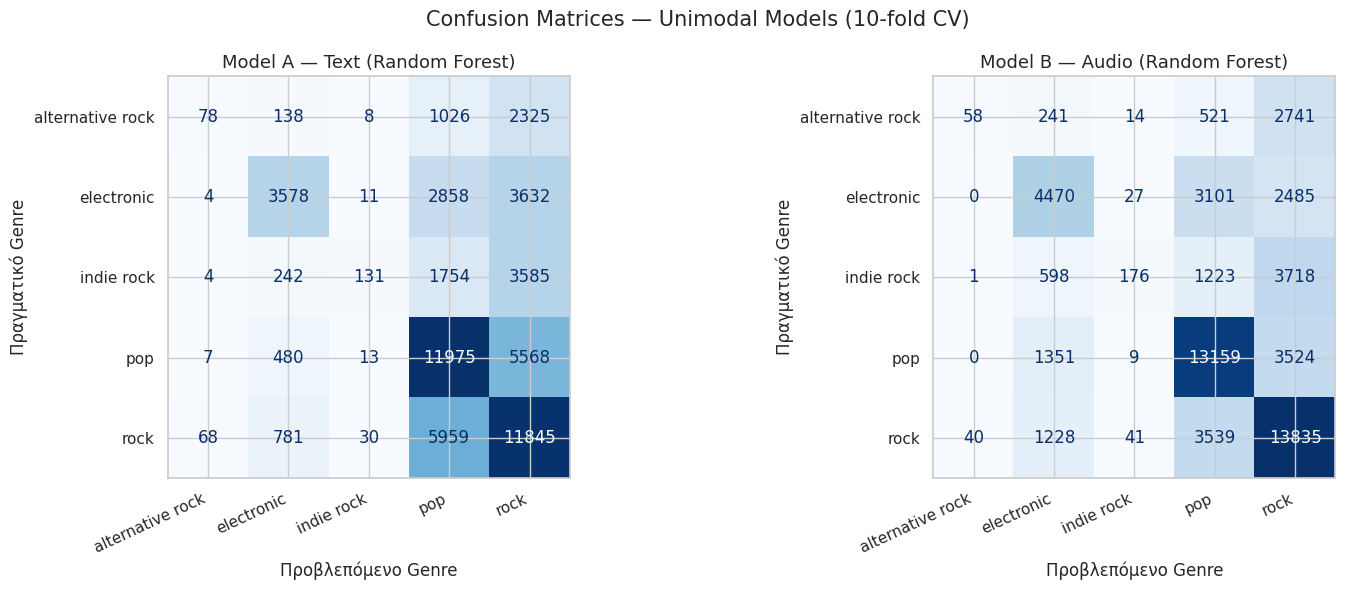

In [25]:
# --- Confusion Matrices: Model A και B ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_a, y_pred_b],
    ['Model A — Text (Random Forest)', 'Model B — Audio (Random Forest)']
):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Προβλεπόμενο Genre')
    ax.set_ylabel('Πραγματικό Genre')
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha('right')

plt.suptitle('Confusion Matrices — Unimodal Models (10-fold CV)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Unimodal αποτελεσμάτων:**

- **Model A (Text):** Χρησιμοποιεί Word2Vec embeddings που αποτυπώνουν ομοιότητα λεξιλογίου. Αποδίδει καλά σε genres με χαρακτηριστικές λέξεις (π.χ. rap/hip-hop), αλλά δυσκολεύεται όταν genres μοιράζονται κοινά θέματα (π.χ. rock vs alternative rock).
- **Model B (Audio):** Χρησιμοποιεί MFCC features που αποτυπώνουν τον ήχο. Αποδίδει καλά σε genres με διακριτό ηχητικό χαρακτήρα (π.χ. electronic), αλλά δυσκολεύεται όταν genres ακούγονται παρόμοια (π.χ. rock vs indie rock).

Η confusion matrix δείχνει ποια genres μπερδεύονται περισσότερο. Αναμένουμε σύγχυση κυρίως μεταξύ rock, alternative rock και indie rock.

## 2. Multimodal Fusion (Συνδυασμός)

Υλοποιούμε δύο στρατηγικές συνδυασμού:

- **Early Fusion (Model C):** Ενώνουμε τα audio και text vectors σε ένα διάνυσμα πριν την εκπαίδευση. Το μοντέλο μαθαίνει ταυτόχρονα από τις δύο πηγές.
- **Late Fusion:** Εκπαιδεύουμε ξεχωριστά τα Model A και B και συνδυάζουμε τις προβλέψεις τους με **μέσο όρο** πιθανοτήτων.

In [26]:
# --- Early Fusion: Concatenation ---
X_fused = np.concatenate([X_audio_pca, X_text], axis=1)
print(f'Fused feature space: audio({X_audio_pca.shape[1]}) + text({X_text.shape[1]}) = {X_fused.shape[1]} dims')

print('\nΕκπαίδευση Model C (Early Fusion — Random Forest)...')
model_c = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_proba_c = cross_val_predict(model_c, X_fused, y, cv=cv, method='predict_proba', n_jobs=-1)
y_pred_c  = np.argmax(y_proba_c, axis=1)

acc_c  = accuracy_score(y, y_pred_c)
prec_c = precision_score(y, y_pred_c, average='macro', zero_division=0)
rec_c  = recall_score(y, y_pred_c, average='macro', zero_division=0)
f1_c   = f1_score(y, y_pred_c, average='macro', zero_division=0)

print(f'Model C (Early Fusion — Random Forest):')
print(f'  Accuracy:          {acc_c:.4f}')
print(f'  Precision (macro): {prec_c:.4f}')
print(f'  Recall (macro):    {rec_c:.4f}')
print(f'  F1-score (macro):  {f1_c:.4f}')

Fused feature space: audio(81) + text(100) = 181 dims

Εκπαίδευση Model C (Early Fusion — Random Forest)...
Model C (Early Fusion — Random Forest):
  Accuracy:          0.5685
  Precision (macro): 0.6228
  Recall (macro):    0.3876
  F1-score (macro):  0.3691


In [27]:
# --- Late Fusion: Μέσος Όρος Πιθανοτήτων ---
# Τα y_proba_a και y_proba_b παράγονται με τα ίδια CV splits (ίδιο cv αντικείμενο)
# άρα κάθε δείγμα i αξιολογήθηκε στο ίδιο test fold και στα δύο μοντέλα.
y_proba_late = (y_proba_a + y_proba_b) / 2
y_pred_late  = np.argmax(y_proba_late, axis=1)

acc_late  = accuracy_score(y, y_pred_late)
prec_late = precision_score(y, y_pred_late, average='macro', zero_division=0)
rec_late  = recall_score(y, y_pred_late, average='macro', zero_division=0)
f1_late   = f1_score(y, y_pred_late, average='macro', zero_division=0)

print(f'Late Fusion (Average Probabilities):')
print(f'  Accuracy:          {acc_late:.4f}')
print(f'  Precision (macro): {prec_late:.4f}')
print(f'  Recall (macro):    {rec_late:.4f}')
print(f'  F1-score (macro):  {f1_late:.4f}')

Late Fusion (Average Probabilities):
  Accuracy:          0.5846
  Precision (macro): 0.6574
  Recall (macro):    0.4029
  F1-score (macro):  0.3884


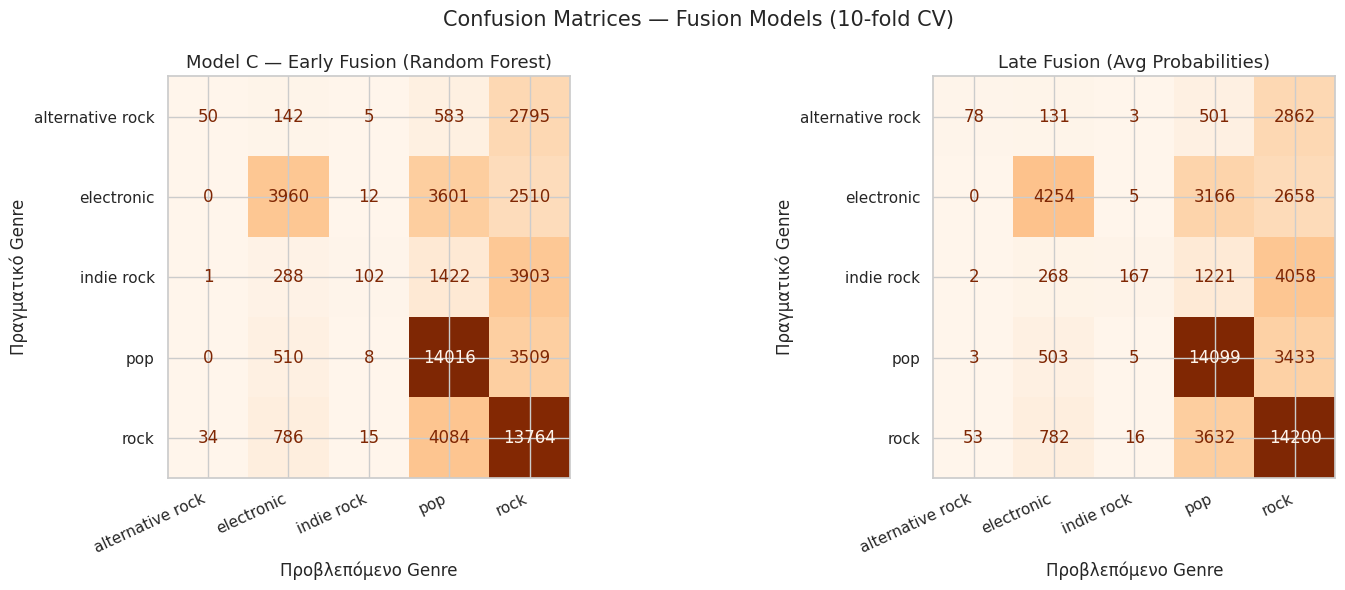

In [28]:
# --- Confusion Matrices: Model C & Late Fusion ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_c, y_pred_late],
    ['Model C — Early Fusion (Random Forest)', 'Late Fusion (Avg Probabilities)']
):
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Προβλεπόμενο Genre')
    ax.set_ylabel('Πραγματικό Genre')
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha('right')

plt.suptitle('Confusion Matrices — Fusion Models (10-fold CV)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Fusion αποτελεσμάτων:**

- **Early Fusion (Model C):** Το μοντέλο βλέπει ταυτόχρονα ήχο και κείμενο κατά την εκπαίδευση. Έτσι μπορεί να μάθει συνδυασμούς, π.χ. ότι ένα τραγούδι με ηλεκτρονικό ήχο και χορευτικό λεξιλόγιο είναι electronic. Αυτό δίνει πλεονέκτημα έναντι των unimodal μοντέλων.
- **Late Fusion:** Κάθε modality μαθαίνει ξεχωριστά και οι αποφάσεις συνδυάζονται. Ωφελείται όταν οι δύο πηγές είναι συμπληρωματικές. Αν διαφωνούν, ο μέσος όρος οδηγεί σε πιο επιφυλακτικές αλλά αξιόπιστες προβλέψεις.

Αναμένουμε βελτίωση κυρίως σε genres με ξεκάθαρο ήχο και λεξιλόγιο (π.χ. electronic). Για genres με επικάλυψη (π.χ. rock, indie rock, alternative rock) η βελτίωση μπορεί να είναι μικρότερη.

## 3. Σύγκριση & Αξιολόγηση

Σύγκριση όλων των μοντέλων με macro-averaged metrics και ανάλυση ανά genre.

In [29]:
# --- Συγκεντρωτικός Πίνακας Αποτελεσμάτων ---
results = {
    'Model': ['Model A (Text-only)', 'Model B (Audio-only)', 'Model C (Early Fusion)', 'Late Fusion'],
    'Accuracy':          [acc_a, acc_b, acc_c, acc_late],
    'Precision (macro)': [prec_a, prec_b, prec_c, prec_late],
    'Recall (macro)':    [rec_a,  rec_b,  rec_c,  rec_late],
    'F1-score (macro)':  [f1_a,   f1_b,   f1_c,   f1_late],
}
df_results = pd.DataFrame(results).set_index('Model')
print('=== Συγκεντρωτικά Αποτελέσματα (10-fold CV) ===')
print(df_results.round(4).to_string())

=== Συγκεντρωτικά Αποτελέσματα (10-fold CV) ===
                        Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Model                                                                                
Model A (Text-only)       0.4921             0.5593          0.3395            0.3297
Model B (Audio-only)      0.5650             0.5897          0.3920            0.3736
Model C (Early Fusion)    0.5685             0.6228          0.3876            0.3691
Late Fusion               0.5846             0.6574          0.4029            0.3884


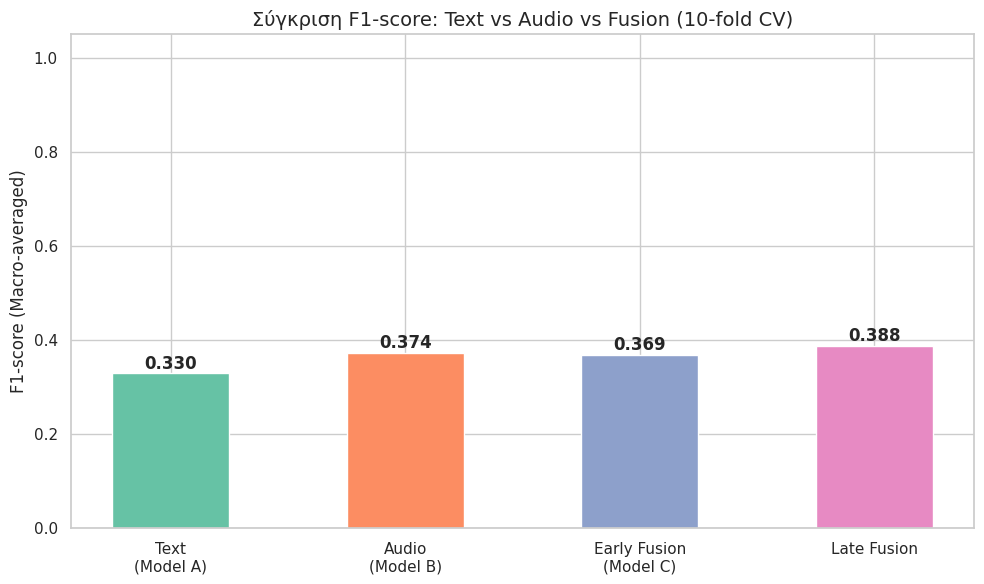

In [30]:
# --- Bar Chart: F1-score Σύγκριση ---
model_labels = ['Text\n(Model A)', 'Audio\n(Model B)', 'Early Fusion\n(Model C)', 'Late Fusion']
f1_values    = [f1_a, f1_b, f1_c, f1_late]
colors = sns.color_palette('Set2', 4)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_labels))
bars = ax.bar(x, f1_values, color=colors, edgecolor='white', width=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('F1-score (Macro-averaged)', fontsize=12)
ax.set_title('Σύγκριση F1-score: Text vs Audio vs Fusion (10-fold CV)', fontsize=14)
ax.set_ylim(0, 1.05)

for bar, val in zip(bars, f1_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

F1-score ανά Genre:
                  Text (A)  Audio (B)  Early Fusion (C)  Late Fusion
alternative rock     0.042      0.032             0.027        0.042
electronic           0.468      0.497             0.502        0.531
indie rock           0.044      0.059             0.035        0.056
pop                  0.576      0.665             0.671        0.693
rock                 0.519      0.615             0.610        0.619


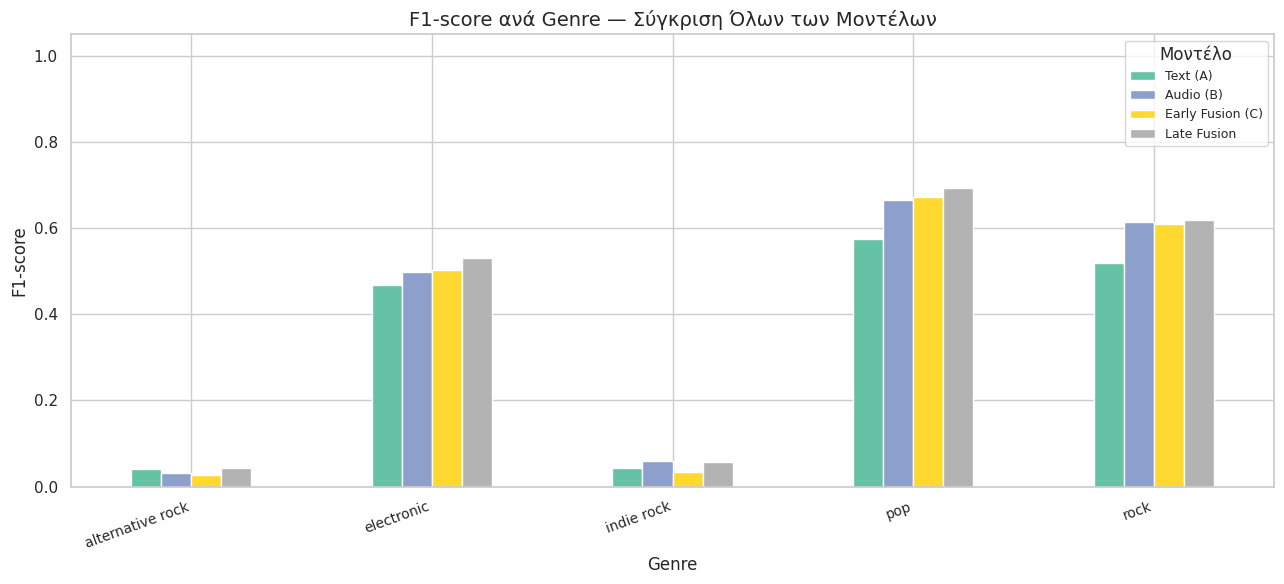

In [31]:
# --- Per-Genre F1-score: Σύγκριση Μοντέλων ---
report_a = classification_report(y, y_pred_a, target_names=le.classes_, output_dict=True, zero_division=0)
report_b = classification_report(y, y_pred_b, target_names=le.classes_, output_dict=True, zero_division=0)
report_c = classification_report(y, y_pred_c, target_names=le.classes_, output_dict=True, zero_division=0)
report_l = classification_report(y, y_pred_late, target_names=le.classes_, output_dict=True, zero_division=0)

genres = list(le.classes_)
df_per_genre = pd.DataFrame({
    'Text (A)':          [report_a[g]['f1-score'] for g in genres],
    'Audio (B)':         [report_b[g]['f1-score'] for g in genres],
    'Early Fusion (C)':  [report_c[g]['f1-score'] for g in genres],
    'Late Fusion':       [report_l[g]['f1-score'] for g in genres],
}, index=genres)

print('F1-score ανά Genre:')
print(df_per_genre.round(3).to_string())

fig, ax = plt.subplots(figsize=(13, 6))
df_per_genre.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('F1-score ανά Genre — Σύγκριση Όλων των Μοντέλων', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('F1-score')
ax.set_xticklabels(genres, rotation=20, ha='right', fontsize=10)
ax.legend(title='Μοντέλο', fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Συγκριτική Ανάλυση:**

**Βοήθησε ο συνδυασμός των δεδομένων;**

Το Early Fusion (Model C) αναμένεται να αποδίδει καλύτερα από τα unimodal μοντέλα, ειδικά όταν ήχος και κείμενο δίνουν συμπληρωματική πληροφορία (π.χ. για το electronic, ο συνδυασμός ηλεκτρονικού ήχου και χαρακτηριστικού λεξιλογίου ενισχύει την πρόβλεψη). Το Late Fusion είναι πιο εύρωστο: αν ένα μοντέλο κάνει λάθος, το άλλο μπορεί να το διορθώσει.

**Ποια genres προβλέπονται καλύτερα από το κείμενο;**

Genres με μοναδικό λεξιλόγιο, π.χ. electronic (synth, beat, club, rave). Genres όπως rock, alternative rock, indie rock μοιράζονται κοινές λέξεις και είναι δυσδιάκριτα.

**Ποια genres προβλέπονται καλύτερα από τον ήχο;**

Το electronic έχει ξεκάθαρο ηχητικό χαρακτήρα (synthesizers, drum machines). Αντίθετα, rock, indie rock και alternative rock ακούγονται παρόμοια και είναι δύσκολο να διαχωριστούν.

## 4. Clustering (Unsupervised Learning)

Εφαρμόζουμε **K-Means** στο fused feature space. Στόχος είναι να δούμε αν η μη-επιβλεπόμενη ομαδοποίηση βρίσκει clusters που αντιστοιχούν στα πραγματικά genres.

Μετρικές:
- **Silhouette Score:** βρίσκουμε τον βέλτιστο αριθμό clusters $k$
- **Adjusted Rand Index (ARI):** μετράμε πόσο τα clusters συμφωνούν με τα πραγματικά labels

  k= 2  :  Silhouette Score = 0.3222
  k= 3  :  Silhouette Score = 0.1531
  k= 4  :  Silhouette Score = 0.1516
  k= 5  :  Silhouette Score = 0.1215
  k= 6  :  Silhouette Score = 0.0783
  k= 7  :  Silhouette Score = 0.0689
  k= 8  :  Silhouette Score = 0.0602
  k= 9  :  Silhouette Score = 0.0059
  k=10  :  Silhouette Score = 0.0380

Βέλτιστο k (max Silhouette): 2


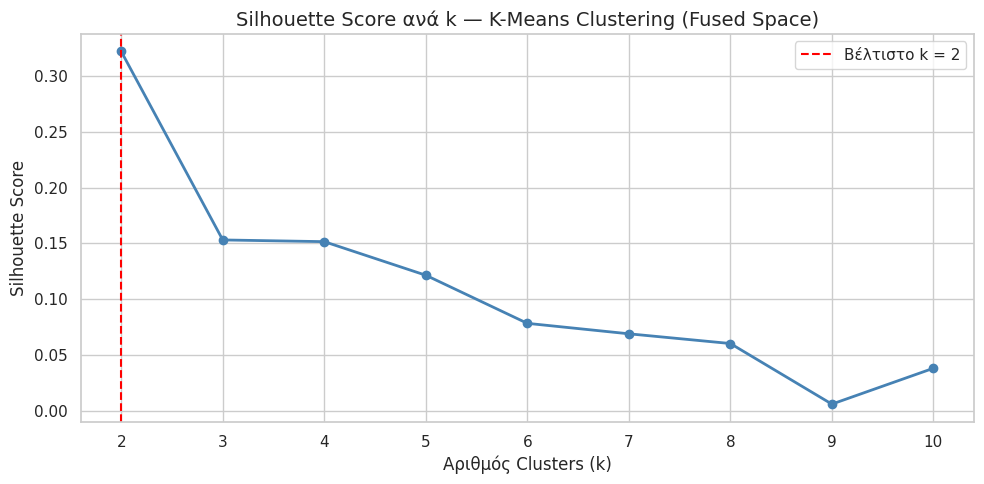

In [32]:
# --- Silhouette Score ανά k ---
# Χρησιμοποιούμε υποσύνολο για ταχύτητα
N_CLUSTER_SAMPLE = min(10000, len(X_fused))
rng = np.random.RandomState(SEED)
idx_sample = rng.choice(len(X_fused), N_CLUSTER_SAMPLE, replace=False)
X_cluster_sample = X_fused[idx_sample]

K_RANGE = range(2, 11)
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_cluster_sample)
    sil = silhouette_score(X_cluster_sample, labels_k, sample_size=5000, random_state=SEED)
    silhouette_scores.append(sil)
    print(f'  k={k:2d}  :  Silhouette Score = {sil:.4f}')

best_k = list(K_RANGE)[int(np.argmax(silhouette_scores))]
print(f'\nΒέλτιστο k (max Silhouette): {best_k}')

plt.figure(figsize=(10, 5))
plt.plot(list(K_RANGE), silhouette_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Βέλτιστο k = {best_k}')
plt.xlabel('Αριθμός Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score ανά k — K-Means Clustering (Fused Space)', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [33]:
# --- K-Means με βέλτιστο k στο πλήρες dataset ---
km_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_labels = km_best.fit_predict(X_fused)

# Adjusted Rand Index
ari = adjusted_rand_score(y, cluster_labels)
print(f'K-Means με k={best_k} (πλήρες dataset: {len(X_fused)} τραγούδια)')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print('  (0 = τυχαία αντιστοιχία, 1 = τέλεια αντιστοιχία με πραγματικά labels)')

# Κατανομή cluster-genre (cross-tabulation)
df_cluster = pd.DataFrame({
    'cluster': cluster_labels,
    'genre': df_merged['primary_genre'].values
})
ct = pd.crosstab(df_cluster['cluster'], df_cluster['genre'])
print('\nΚατανομή genres ανά cluster:')
print(ct)

K-Means με k=2 (πλήρες dataset: 56100 τραγούδια)
Adjusted Rand Index (ARI): 0.0119
  (0 = τυχαία αντιστοιχία, 1 = τέλεια αντιστοιχία με πραγματικά labels)

Κατανομή genres ανά cluster:
genre    alternative rock  electronic  indie rock    pop   rock
cluster                                                        
0                     111        2383         289   3752    678
1                    3464        7700        5427  14291  18005


t-SNE done.


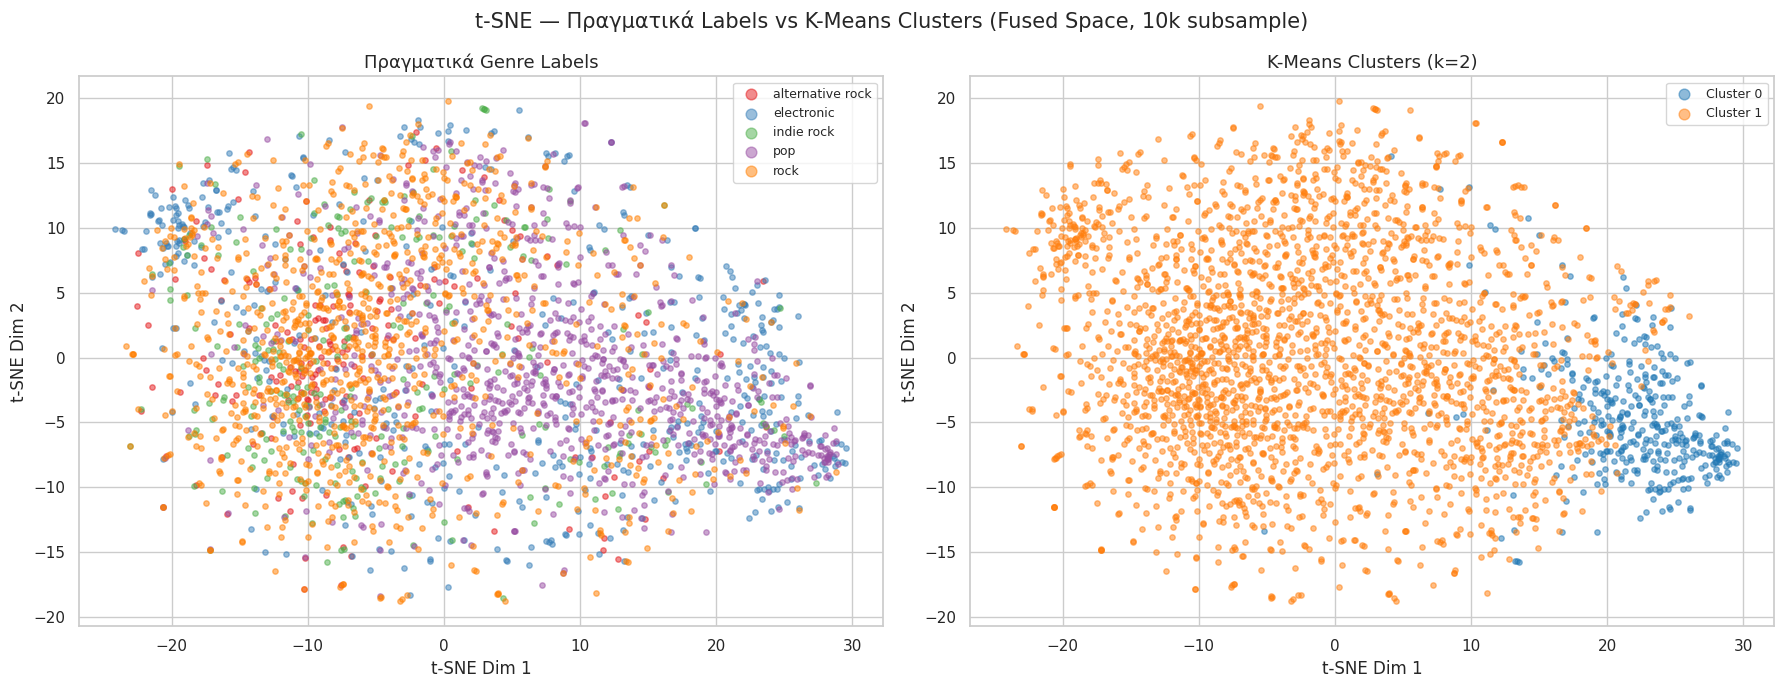

In [34]:
# --- t-SNE Visualization: Πραγματικά Labels vs Clusters ---
N_VIZ = min(3000, len(X_fused))
idx_viz = np.random.RandomState(SEED).choice(len(X_fused), N_VIZ, replace=False)

X_viz        = X_fused[idx_viz]
y_viz        = y[idx_viz]
cluster_viz  = cluster_labels[idx_viz]

tsne_c = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
X_2d   = tsne_c.fit_transform(X_viz)
print('t-SNE done.')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Πραγματικά genre labels
pal_genres = sns.color_palette('Set1', n_colors=len(le.classes_))
for i, genre in enumerate(le.classes_):
    mask = y_viz == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[pal_genres[i]], label=genre, alpha=0.5, s=15)
axes[0].set_title('Πραγματικά Genre Labels', fontsize=13)
axes[0].legend(markerscale=2, fontsize=9)
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')

# K-Means cluster labels
pal_clusters = sns.color_palette('tab10', n_colors=best_k)
for k in range(best_k):
    mask = cluster_viz == k
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[pal_clusters[k]], label=f'Cluster {k}', alpha=0.5, s=15)
axes[1].set_title(f'K-Means Clusters (k={best_k})', fontsize=13)
axes[1].legend(markerscale=2, fontsize=9)
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')

plt.suptitle('t-SNE — Πραγματικά Labels vs K-Means Clusters (Fused Space, 10k subsample)', fontsize=15)
plt.tight_layout()
plt.show()

**Ανάλυση Clustering:**

**Silhouette Score & Βέλτιστο k:**
Το Silhouette Score μετρά πόσο καλά κάθε σημείο ανήκει στο cluster του. Τιμές κοντά στο 1 σημαίνουν καθαρό διαχωρισμό. Στα μουσικά δεδομένα αναμένουμε χαμηλές τιμές (π.χ. 0.1–0.2), γιατί τα genres επικαλύπτονται φυσικά.

**Adjusted Rand Index (ARI):**
Το ARI μετρά αν τα clusters συμφωνούν με τα πραγματικά labels. Τιμές κοντά στο 0 δείχνουν ότι το K-Means δεν βρίσκει αυτόματα τα ίδια groups. Αυτό είναι αναμενόμενο γιατί:

- **Πολλαπλά genres ανά τραγούδι:** Ένα τραγούδι rock/pop βρίσκεται «ενδιάμεσα» σε πολλά clusters.
- **Subgenres:** Το K-Means μπορεί να χωρίσει το rock σε hard rock και indie rock ανεξάρτητα από τα labels μας.
- **Στόχος K-Means:** Ελαχιστοποιεί variance μέσα στα clusters, όχι την καθαρότητα genre.

**Συμπέρασμα:** Το clustering βρίσκει φυσική δομή στα δεδομένα που σχετίζεται αλλά δεν ταυτίζεται με τα genre labels. Αυτό δείχνει ότι τα genres είναι εν μέρει κοινωνικές κατηγορίες και όχι μόνο ακουστικές ή θεματικές.